In [3]:
#if (!require("BiocManager", quietly = TRUE))
    #install.packages("BiocManager")

#BiocManager::install("MPRAnalyze")
#Format the data into MPRA project
library("MPRAnalyze")
library("BiocParallel")

dropEnhancer <- function(df_RNA){
    row.names(df_RNA) <-df_RNA$enhancer_id	
    df <- df_RNA[ , !(names(df_RNA) %in% c("enhancer_id"))]
    return(df)
    }
    
dropX <- function(df_RNA){
    row.names(df_RNA) <-df_RNA$X
    df <- df_RNA[ , !(names(df_RNA) %in% c("X"))]
    return(df)
    }

# Function to load data and convert it to matrix after dropping enhancer
load_and_process <- function(filepath, drop_func) {
  df <- read.csv(filepath, header = TRUE,row.names = 1)
  as.matrix(df)
}

register(MulticoreParam(24))
bpparam <- MulticoreParam(24, log = TRUE, stop.on.error = FALSE)


# Motif + Allele in one 

In [9]:
df_DNA <- read.csv("read_counts_R1R2/THP1mono20240412Pseudo_DNA_matched_barcodes_reshaped.csv", header=TRUE)
df_RNA <- read.csv("read_counts_R1R2/THP1mono20240412_RNA_matched_barcodes_reshaped.csv", header=TRUE)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Monocyte20240412_barcodes.csv")



df_DNA<-df_DNA[2:nrow(df_DNA), ]
df_RNA<-df_RNA[2:nrow(df_RNA), ]
#Match row names
annot_DNA<-dropX(annot_DNA)
#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID
df_RNA <-as.matrix(dropEnhancer(df_RNA))
df_DNA <-as.matrix(dropEnhancer(df_DNA))

df_DNA <- df_DNA[, !grepl("ZC37|ZC60", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC37|ZC60", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC37|ZC60", rownames(annot_DNA)), ]

#Create MPRA object
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
#                  control=control,
                  BPPARAM = bpparam
                  )
#enhancer level per tissue;
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeComparative(obj = obj, 
                          dnaDesign = ~ Barcode_Allele + Test,
                          rnaDesign = ~ Allele_String,
                          reducedDesign = ~ 1,
                          #mode="scale"
                          )
res <-testLrt(obj)
write.csv(res,"20240813_comparative_THP1Monocyte_allele.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-08-13 11:21:06.953151
Success: TRUE

Task duration:
   user  system elapsed 
  8.257   0.405   9.460 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6166356 329.4   11606951 619.9  8799231 470.0
Vcells 11069333  84.5   19192541 146.5 19192541 146.5

Log messages:
INFO [2024-08-13 11:20:57] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 5
Node: 20
Timestamp: 2024-08-13 11:21:09.422408
Success: TRUE

Task duration:
   user  system elapsed 
 11.757   0.366  12.472 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6167630 329.4   11606951 619.9  8799231 470.0
Vcells 11073733  84.5   19192541 146.5 19192541 146.5

Log messages:
INFO [2024-08-13 11:20:57] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 22
Node: 3
Timestamp: 2024-08-13 11:2

/tmp/ipykernel_9988/1362734460.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.clustermap(pd.merge(df_synthetic[['Naive_THP1mono_ZC111_R']],df_original,left_index = True ,right_index= True).corr('spearman'),vmin=0)


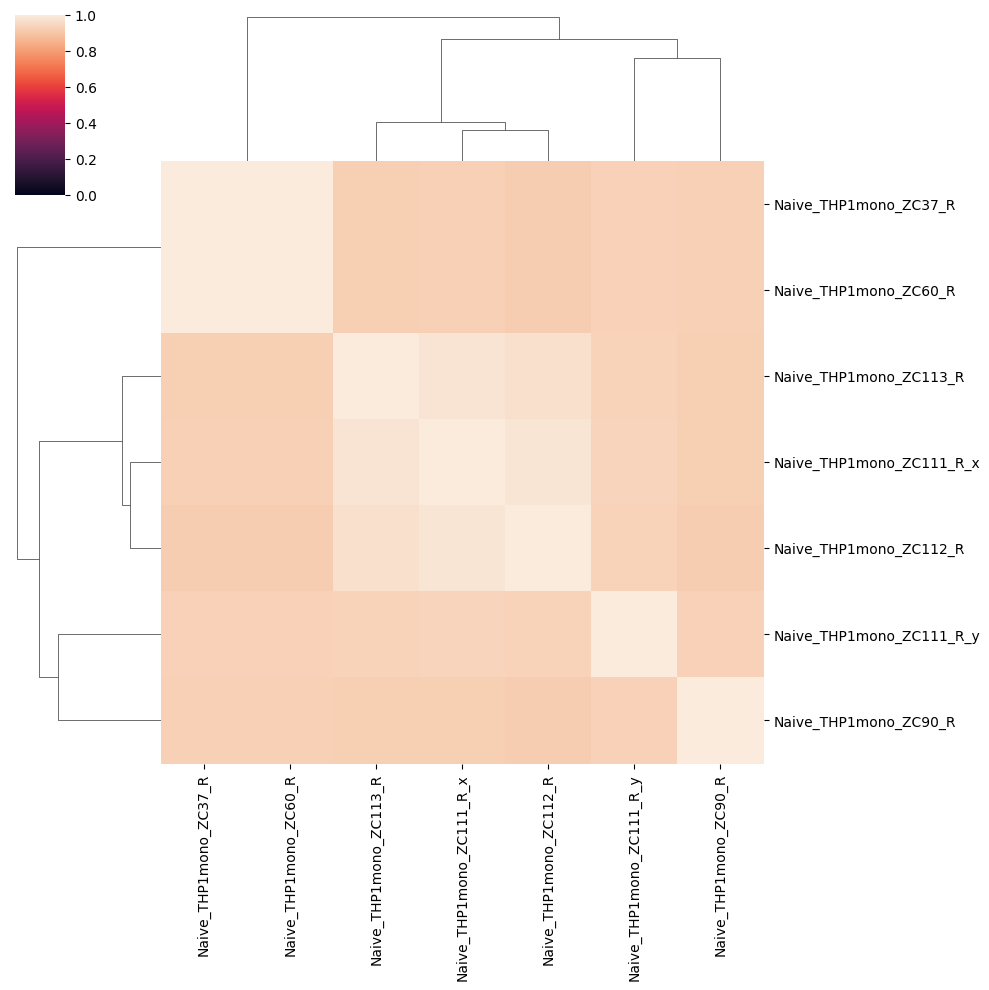

In [36]:
import pandas as pd
df_synthetic = pd.read_csv("read_counts_R1R2/THP1mono20240412_DNA_matched_barcodes.csv",index_col=0)
df_original = pd.read_csv("read_counts_R1R2/THP1mono20240412Pseudo_DNA_matched_barcodes.csv",index_col=0)
import seaborn as sns
sns.clustermap(pd.merge(df_synthetic[['Naive_THP1mono_ZC111_R']],df_original,left_index = True ,right_index= True).corr('spearman'),vmin=0)

# Motif-Allele Comparison

In [2]:
# Load datasets
df_DNA <- load_and_process("read_counts_R1R2/THP1mono20240412Pseudo_DNA_matched_barcodes_motif.csv", dropEnhancer)
df_RNA <- load_and_process("read_counts_R1R2/THP1mono20240412_RNA_matched_barcodes_motif.csv", dropEnhancer)
annot_DNA <- read.csv("annotation_barcodes/mpra3_annot_THP1Monocyte_barcodes_motif.csv",row.names = 1)
df_DNA <- df_DNA[, !grepl("ZC37|ZC60", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC37|ZC60", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC37|ZC60", rownames(annot_DNA)), ]


obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
#                  control=control,
                  BPPARAM = bpparam
                  )
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeComparative(obj = obj, 
                          dnaDesign = ~ Barcode_Allele+Test,
                          rnaDesign = ~ Motif_Allele,
                          reducedDesign = ~ 1,
                          #mode="scale"
                          )
                      
res <-testLrt(obj)
write.csv(res,"20240719_comparative_THP1Monocyte_motif.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-07-19 15:17:35.407018
Success: TRUE

Task duration:
   user  system elapsed 
  1.274   0.227   1.503 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6288064 335.9   12115577 647.1  7290482 389.4
Vcells 11229998  85.7   19262103 147.0 13254239 101.2

Log messages:
INFO [2024-07-19 15:17:33] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 10
Node: 15
Timestamp: 2024-07-19 15:17:36.389832
Success: TRUE

Task duration:
   user  system elapsed 
  1.908   0.169   2.077 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6289435 335.9   12115577 647.1  7290482 389.4
Vcells 11235145  85.8   19262103 147.0 13254239 101.2

Log messages:
INFO [2024-07-19 15:17:33] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 11
Node: 14
Timestamp: 2024-07-19 15

# Allele Only

In [3]:
# Load datasets
df_DNA <- load_and_process("read_counts_R1R2/allele_only/THP1mono20240412Pseudo_DNA_matched_barcodes_reshaped_allele.csv", dropEnhancer)
df_RNA <- load_and_process("read_counts_R1R2/allele_only/THP1mono20240412_RNA_matched_barcodes_reshaped_allele.csv", dropEnhancer)
annot_DNA <- read.csv("annotation_barcodes/mpra3_annot_THP1Monocyte20240412_barcodes.csv",row.names = 1)
df_DNA <- df_DNA[, !grepl("ZC37|ZC60", colnames(df_DNA))]
df_RNA <- df_RNA[, !gsrepl("ZC37|ZC60", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC37|ZC60", rownames(annot_DNA)), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
#                  control=control,
                  BPPARAM = bpparam
                  )
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeComparative(obj = obj, 
                          dnaDesign = ~ Barcode_Allele+Test,
                          rnaDesign = ~ Allele_String,
                          reducedDesign = ~ 1,
                          #mode="scale"
                          )
                      
res <-testLrt(obj)
write.csv(res,"20240719_comparative_THP1Monocyte_alleleOnly.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-07-19 15:18:28.900047
Success: TRUE

Task duration:
   user  system elapsed 
  4.432   0.192   4.626 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6295572 336.3   12115577 647.1  7351158 392.6
Vcells 11288228  86.2   19262103 147.0 13966378 106.6

Log messages:
INFO [2024-07-19 15:18:24] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 6
Node: 19
Timestamp: 2024-07-19 15:18:30.309633
Success: TRUE

Task duration:
   user  system elapsed 
  6.052   0.182   6.234 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6295912 336.3   12115577 647.1  7351158 392.6
Vcells 11290300  86.2   19262103 147.0 13966378 106.6

Log messages:
INFO [2024-07-19 15:18:24] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 3
Node: 22
Timestamp: 2024-07-19 15:1